In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 442MB/s]


In [3]:
import zipfile
with zipfile.ZipFile('/content/telco-customer-churn.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns = ['customerID'], inplace=True)

In [8]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [9]:
for col in df.columns:
  # if df[col].dtype == 'object':
    # print(df[col].value_counts())
    print(col, df[col].unique())

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges ['29.85' '1889

In [10]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [15]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
  print(col, len(df[df[col] == ' ']))    # prints no. of empty string

tenure 0
MonthlyCharges 0
TotalCharges 11


In [16]:
df['TotalCharges'] = df['TotalCharges'].replace({" ":'0.0'}).astype(float)

In [17]:
def plot_dist(df, col):
  plt.figure(figsize=(14,6))
  plt.subplot(121)
  sns.histplot(df[col], bins=20, kde=True)
  plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2, label='mean')
  plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2, label='median')
  plt.legend()

  plt.subplot(122)
  sns.boxplot(x=df[col])

  plt.show()


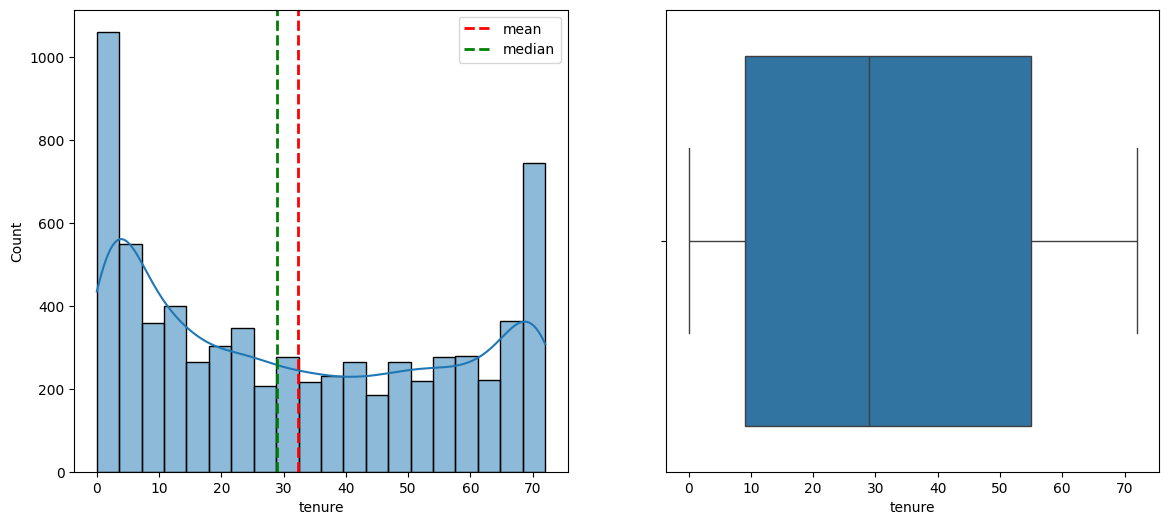

In [18]:
plot_dist(df, 'tenure')

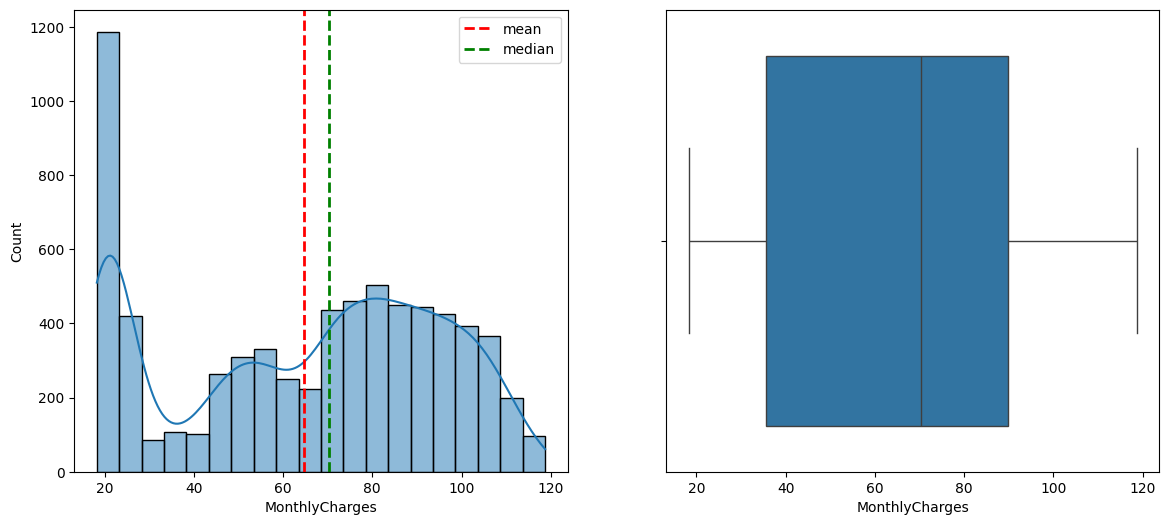

In [19]:
plot_dist(df, 'MonthlyCharges')

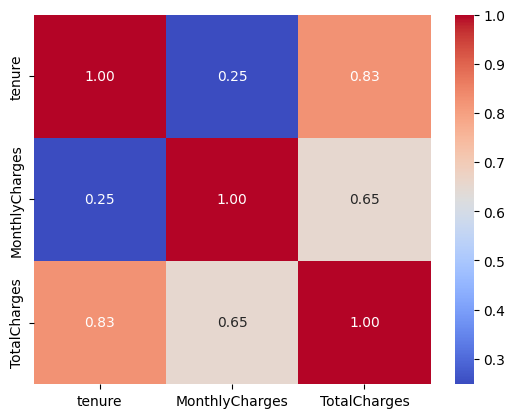

In [20]:
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

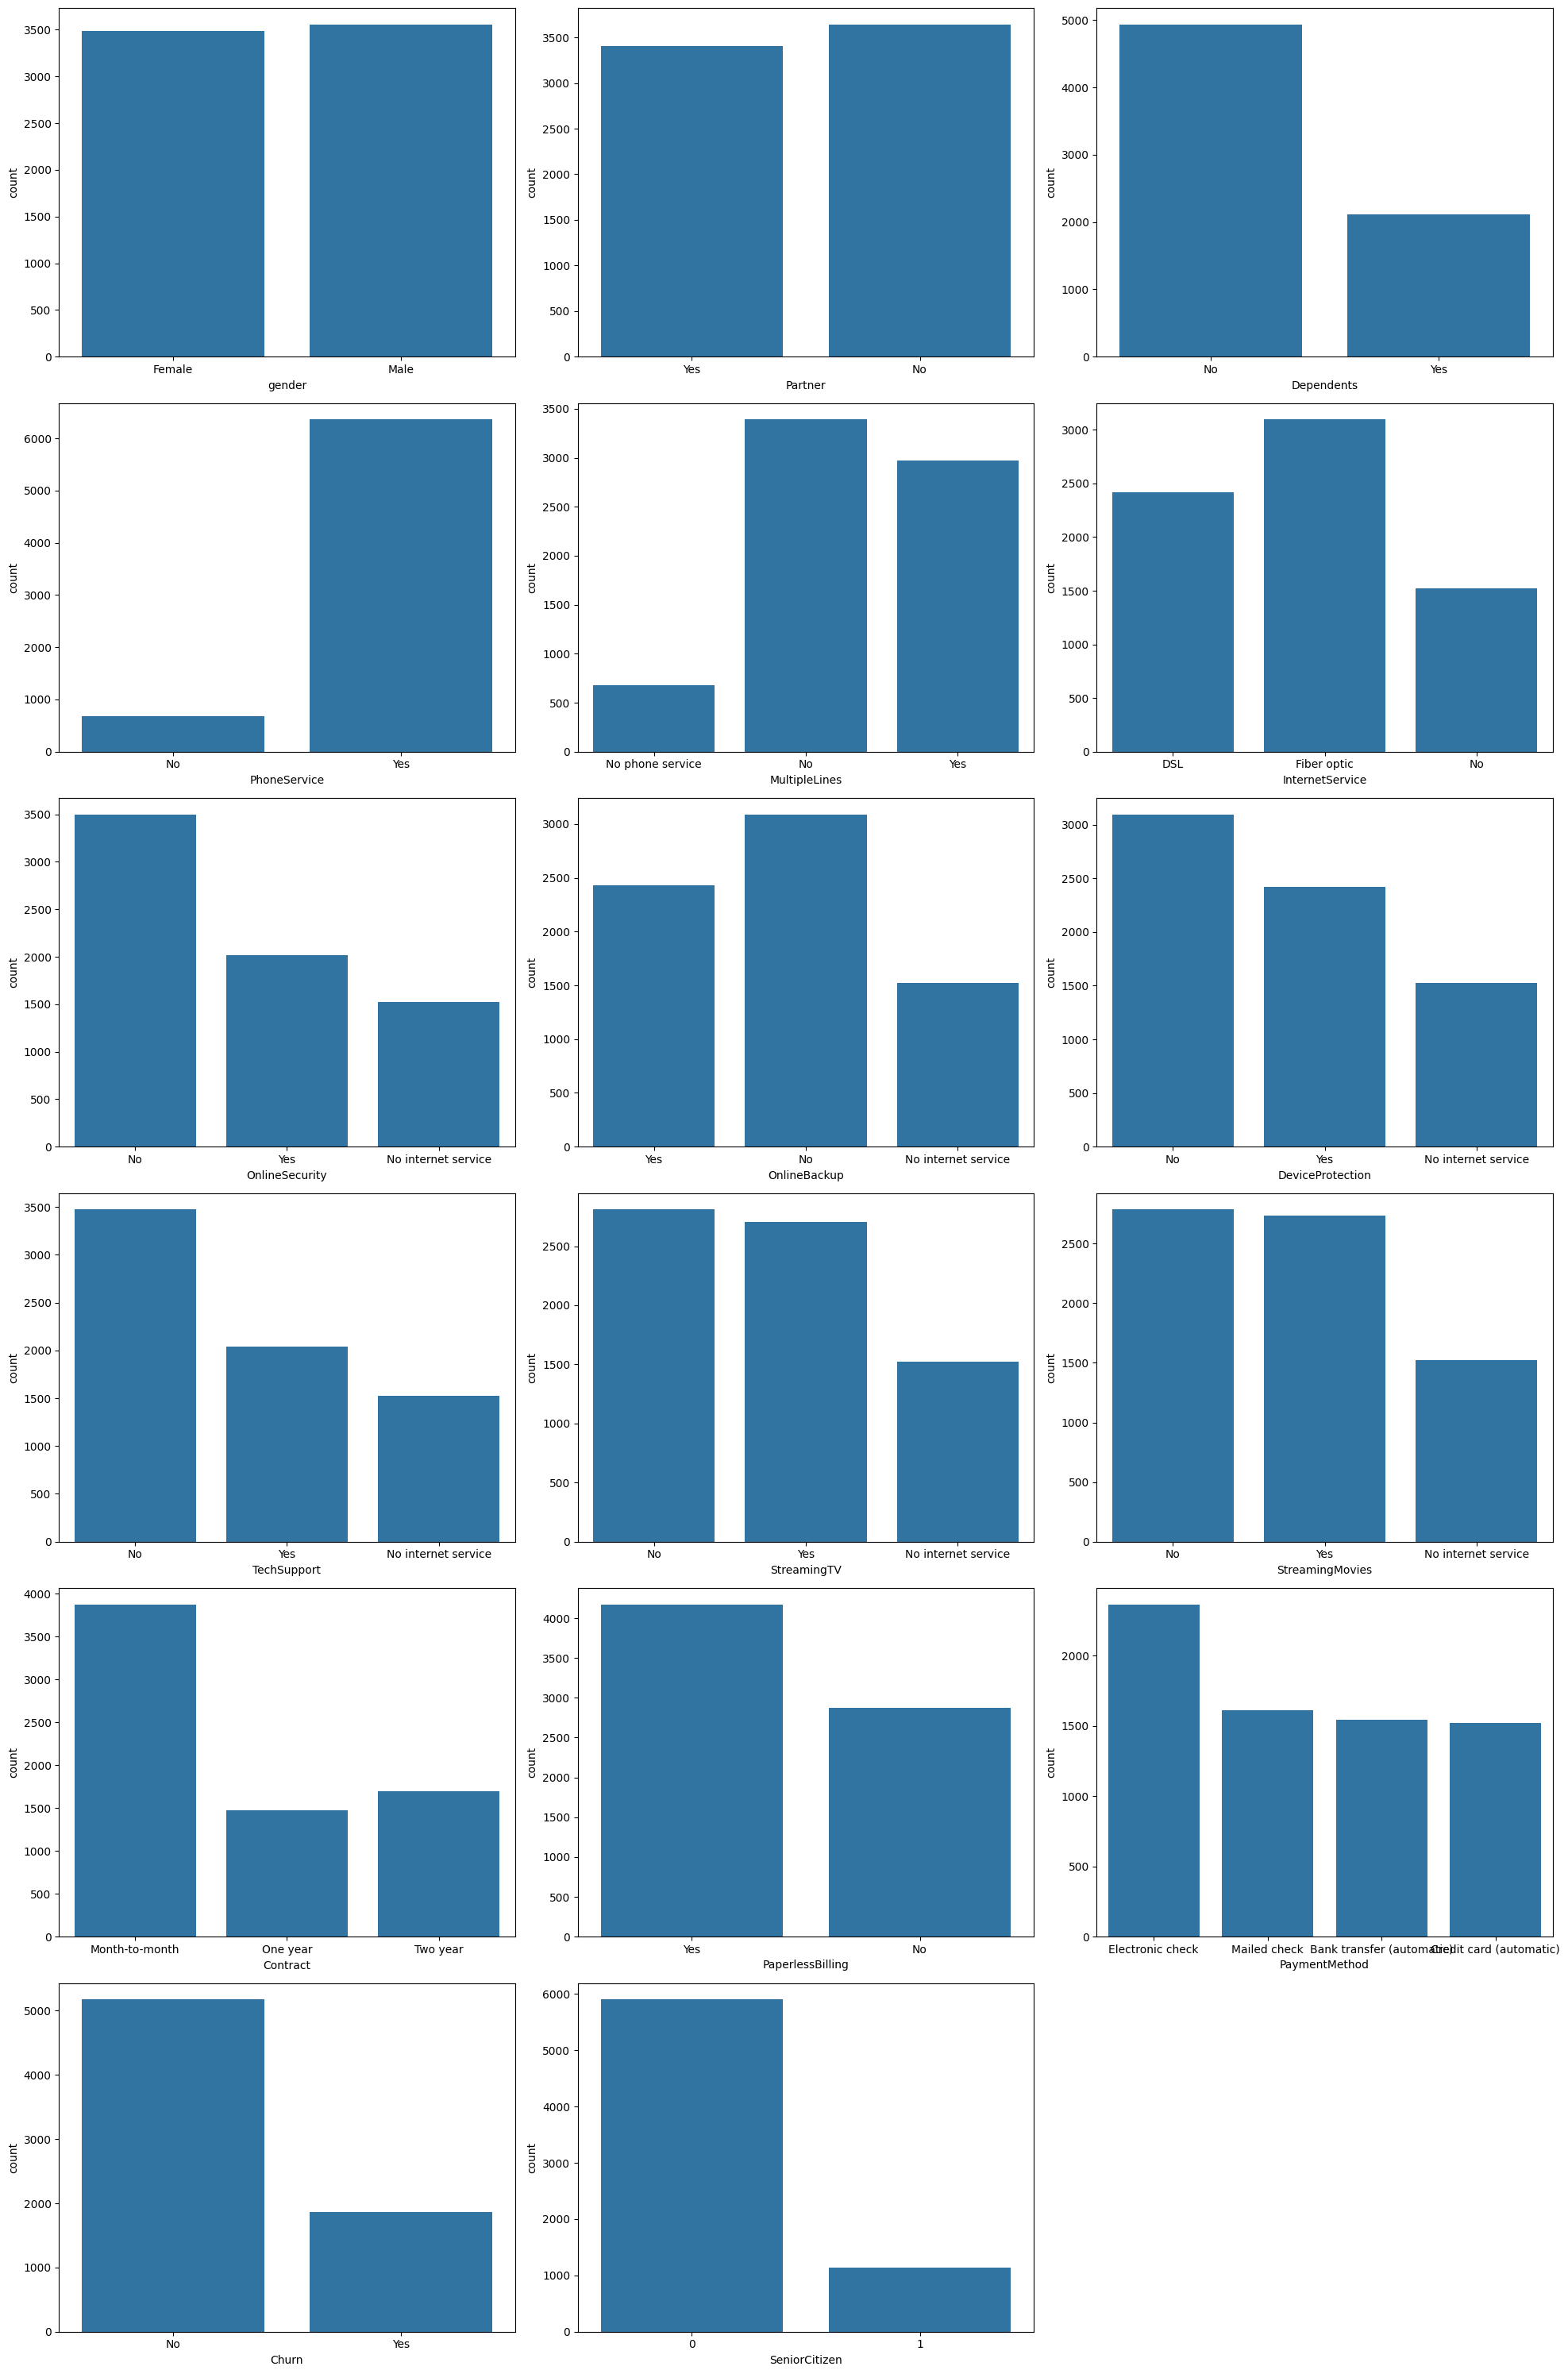

In [21]:
categorical_col = df.select_dtypes(include='object').columns.to_list() + ['SeniorCitizen']

plt.figure(figsize=(20,30))
for i,col in enumerate(categorical_col):
  plt.subplot(6,3,i+1)
  # sns.countplot(data=df, x=col, hue='Churn')
  sns.countplot(x=df[col])
plt.tight_layout()
plt.show()


In [52]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.drop(columns = ['customerID'], inplace=True)

# Convert 'TotalCharges' to numeric, handling empty strings
df['TotalCharges'] = df['TotalCharges'].replace({" ":'0.0'}).astype(float)

object_col = df.select_dtypes(include='object').columns.to_list()
object_col.remove('Churn') # Exclude the target variable from encoding

from sklearn.preprocessing import LabelEncoder
encoders = {}

for col in object_col:
  le = LabelEncoder() # Create a new LabelEncoder for each column
  df[col] = le.fit_transform(df[col])
  encoders[col] = le

In [53]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,No
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,No
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,Yes
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,No
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,Yes


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])


In [55]:
df['Churn'].value_counts()       # Highly imbalanced

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [56]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, recall_score, precision_score, f1_score

In [66]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Churn'), df['Churn'], test_size=0.2, random_state=42)

In [ ]:
# y_train = y_train.map({'No':0, 'Yes':1})
# y_test = y_test.map({'No':0, 'Yes':1})




array([0, 0, 1, ..., 0, 1, 0], shape=(5634,))

In [67]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [68]:
y_train.value_counts(), y_train_smote.value_counts()

(Churn
 No     4138
 Yes    1496
 Name: count, dtype: int64,
 Churn
 No     4138
 Yes    4138
 Name: count, dtype: int64)

In [ ]:
le = LabelEncoder()
y_train_smote = le.fit_transform(y_train_smote)
y_train_smote

array([0, 0, 1, ..., 1, 1, 1], shape=(8276,))

In [81]:
le = LabelEncoder()
y_test = le.fit_transform(y_test)
y_test

array([1, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [70]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

hyperparameters = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5,10,None]
    },
    'XGBoost': {
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
}

In [71]:
best_models = {}

for model_name, model in models.items():
  print(f'Running {model_name}.....')
  grid_search = GridSearchCV(estimator=model, param_grid=hyperparameters[model_name], cv=3, scoring='accuracy')
  grid_search.fit(X_train_smote, y_train_smote)
  best_models[model_name] = grid_search.best_estimator_
  print(f'Best parameters for {model_name}: {grid_search.best_params_}')
  print(f'Best accuracy for {model_name}: {grid_search.best_score_: .2f} \n')

Running Random Forest.....
Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 100}
Best accuracy for Random Forest:  0.83 

Running XGBoost.....
Best parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 7}
Best accuracy for XGBoost:  0.81 



In [72]:
best_models

{'Random Forest': RandomForestClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)}

In [73]:
import pickle
with open('best_models.pkl', 'wb') as f:
  pickle.dump(best_models['XGBoost'], f)

In [74]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [75]:
# y_pred = best_models['Random Forest'].predict(X_test)
y_pred_prob = best_models['XGBoost'].predict_proba(X_test)[:,1]
threshold = 0.4
y_pred = (y_pred_prob >= threshold).astype(int)

In [76]:
y_pred_prob, y_pred

(array([0.7755954 , 0.370485  , 0.00774163, ..., 0.04718882, 0.00249289,
        0.59444046], shape=(1409,), dtype=float32),
 array([1, 0, 0, ..., 0, 0, 1], shape=(1409,)))

### Feature Importance (SHAP)

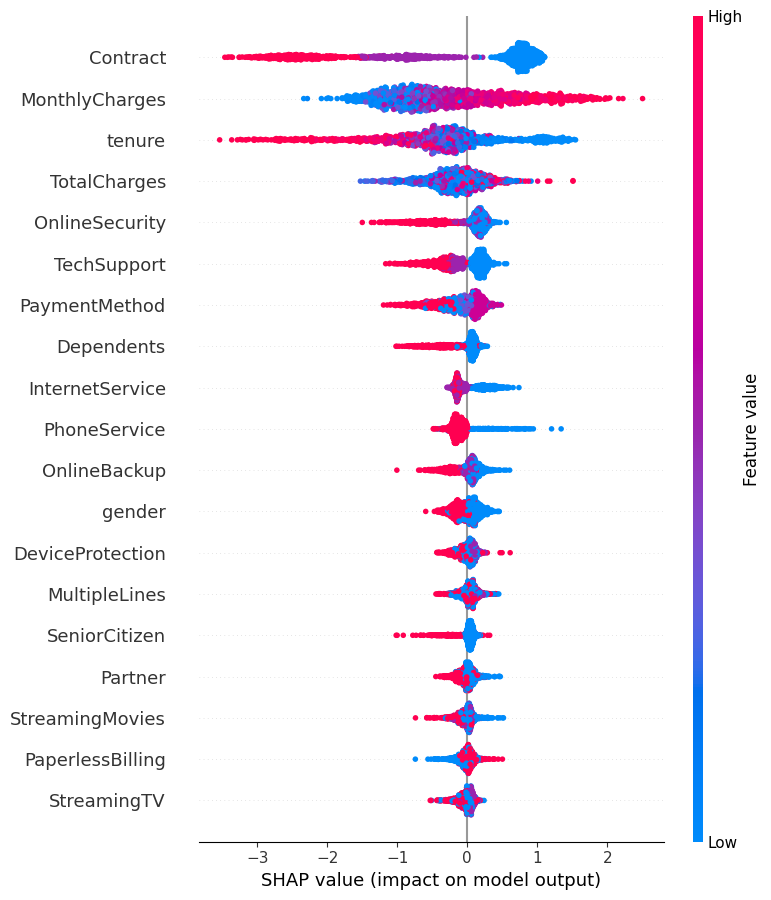

In [77]:
import shap

explainer = shap.TreeExplainer(best_models['XGBoost'])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

### Local SHAP value

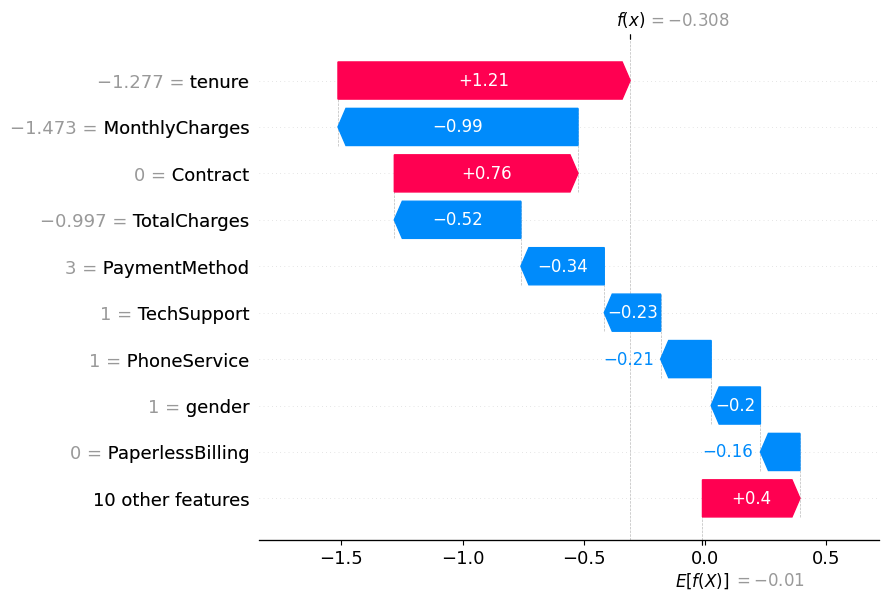

In [78]:
# shap.initjs()
# shap.force_plot(explainer.expected_value,
#                 shap_values[10],
#                 X_test.iloc[10],
#                 matplotlib=True)

explainer = shap.TreeExplainer(best_models['XGBoost'])

# Do it this way to get Explanation object
shap_values_obj = explainer(X_test)  # <-- use () not .shap_values()

# Now waterfall will work
shap.plots.waterfall(shap_values_obj[10])

In [79]:
churn_rate = len(np.where(y_pred==1)[0])/len(y_pred)*100
churn_rate

38.821859474804825

In [82]:
print(f'Accuracy: {accuracy_score(y_test, y_pred): .2f}')
print(f'ROC-AUC score: {roc_auc_score(y_test, y_pred): .2f}')
print(f'Confusion matrix: \n{confusion_matrix(y_test, y_pred)}')
print(f'Classification report: \n{classification_report(y_test, y_pred)}')
print(f'Recall score: {recall_score(y_test, y_pred):.3f}')
print(f'Precision score: {precision_score(y_test, y_pred):.3f}')
print(f'F1 score: {f1_score(y_test, y_pred):.3f}')


# threshold=0.5,  F1-score: 0.613
# threshold=0.41, F1-score = 0.626

Accuracy:  0.75
ROC-AUC score:  0.76
Confusion matrix: 
[[775 261]
 [ 87 286]]
Classification report: 
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1036
           1       0.52      0.77      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

Recall score: 0.767
Precision score: 0.523
F1 score: 0.622


In [83]:
confusion_matrix(y_test, y_pred)[0][1], confusion_matrix(y_test, y_pred)[1][0]

(np.int64(261), np.int64(87))

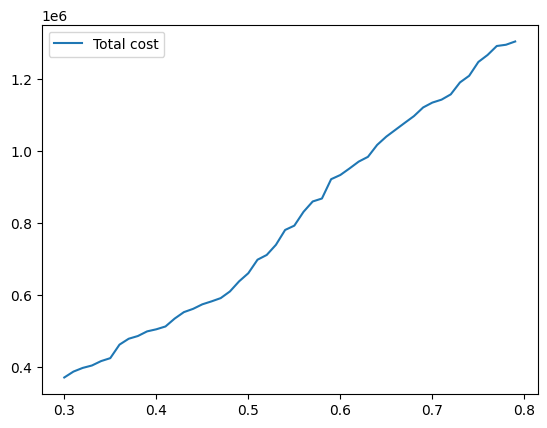

In [84]:
C_FP = 300
C_FN = 5000

Total_cost = {}
f1 = {}
precision = {}
recall = {}

for i in range(30,80):
    threshold = i/100
    y_pred_prob = best_models['Random Forest'].predict_proba(X_test)[:,1]
    y_pred = (y_pred_prob >= threshold).astype(int)
    fp, fn = confusion_matrix(y_test, y_pred)[0][1], confusion_matrix(y_test, y_pred)[1][0]
    cost = fn*C_FN + fp*C_FP
    Total_cost[threshold] = cost
    f1[threshold] = f1_score(y_test, y_pred)
    precision[threshold] = precision_score(y_test, y_pred)
    recall[threshold] = recall_score(y_test, y_pred)

# plt.plot(f1.keys(), f1.values(), label = 'F1-score')
plt.plot(Total_cost.keys(), Total_cost.values(), label = 'Total cost')
# plt.plot(precision.keys(), precision.values(), label = 'Precision')
# plt.plot(recall.keys(), recall.values(), label = 'recall')
plt.legend()
plt.show()




    
    

In [85]:
with open('encoders.pkl', 'wb') as f:
  pickle.dump(encoders, f)
with open('scaler.pkl', 'wb') as f:
  pickle.dump(scaler, f)


In [86]:
with open('best_models.pkl', 'rb') as f:
  best_model = pickle.load(f)
with open('encoders.pkl', 'rb') as f:
  encoders = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
  scaler = pickle.load(f)



In [87]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [115]:
def make_prediction(input_data, loaded_model, encoders, scaler):
  df = pd.DataFrame(input_data, index=[0])
  for col, encoder in encoders.items():
    df[col] = encoder.transform(df[col])
  numerical_col = ['tenure', 'MonthlyCharges', 'TotalCharges']
  df[numerical_col] = scaler.transform(df[numerical_col])
  prediction = loaded_model.predict(df)
  prediction_prob = loaded_model.predict_proba(df)[:,1]
  return 'Churn' if prediction[0] == 1 else 'No churn', prediction_prob[0]

In [ ]:
df[]

In [116]:
example_input = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 10,
    'PhoneService': 'Yes',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No internet service',
    'Contract': 'Two year',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': -50.0,
    'TotalCharges': -1000.0
}

In [117]:
pred, prob = make_prediction(example_input, best_model, encoders, scaler)

print(f'Prediction: {pred} \nChurn probability: {prob*100:.2f}%')

Prediction: No churn 
Churn probability: 1.99%


### Customer Lifetime Value (CLV) Integration
CLV = how much money a customer is worth to the business over their entire relationship.

In [95]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [96]:
df_test = pd.DataFrame()
df_test['churn_probability'] = y_pred_prob
df_test

,churn_probability
0,0.91
1,0.40
2,0.01
3,0.86
4,0.08
...,...
1404,0.04
1405,0.39
1406,0.02
1407,0.04


In [107]:
# Step1: Calcuate CLV

df_test['CLV'] = X_test.iloc[:,17]/(1-df_test['churn_probability'] + 1e-9)


# Step2: Calculate revenue at risk
df_test['rev_at_risk'] = df_test['CLV']*df_test['churn_probability']

# Step3: Segment customers by priority

q75 = df_test['CLV'].quantile(0.75)
q50 = df_test['CLV'].quantile(0.5)

def assign_priority(row):
    if row['churn_probability'] >= 0.7 and row['CLV'] >= q75:
        return 'Critical'        # High churn risk + High value
    elif row['churn_probability'] >= 0.5 and row['CLV'] >= q50:
        return 'High Priority'   # Medium-high churn + Medium value
    elif row['churn_probability'] >= 0.3:
        return 'Monitor'         # Low-medium churn risk
    else:
        return 'Safe'            # Low churn risk

df_test['priority_segment'] = df_test.apply(assign_priority, axis=1)

print(df_test['priority_segment'].value_counts())

priority_segment
Safe             723
Monitor          636
High Priority     31
Critical          19
Name: count, dtype: int64


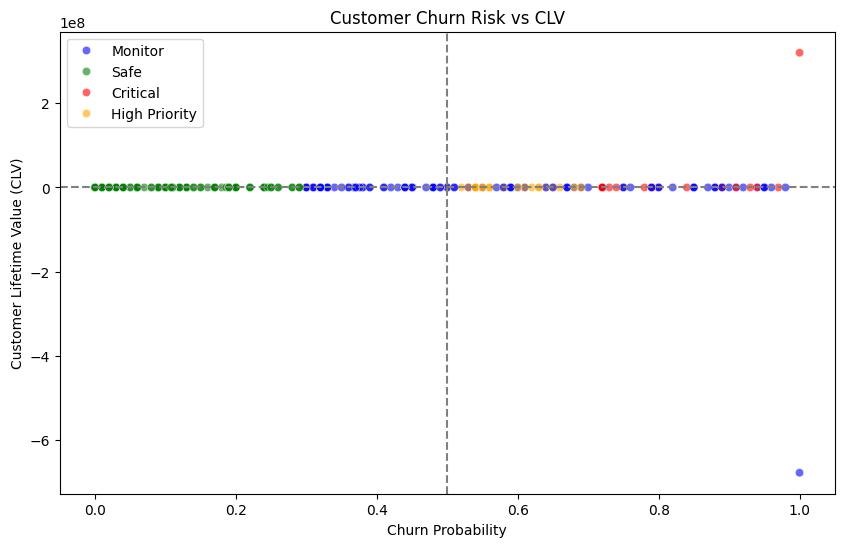

In [108]:
# Step5: Visualize it

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_test,
    x='churn_probability',
    y='CLV',
    hue='priority_segment',
    palette={'Critical': 'red', 'High Priority': 'orange', 
             'Monitor': 'blue', 'Safe': 'green'},
    alpha=0.6
)
plt.axvline(x=0.5, linestyle='--', color='gray')
plt.axhline(y=df_test['CLV'].median(), linestyle='--', color='gray')
plt.title('Customer Churn Risk vs CLV')
plt.xlabel('Churn Probability')
plt.ylabel('Customer Lifetime Value (CLV)')
plt.legend()
plt.show()

In [102]:
# Step 6 — Business Summary Table

summary = df_test.groupby('priority_segment').agg(
    customer_count=('CLV', 'count'),
    avg_CLV=('CLV', 'mean'),
    total_revenue_at_risk=('rev_at_risk', 'sum'),
    avg_churn_probability=('churn_probability', 'mean')
).round(2).sort_values('total_revenue_at_risk', ascending=False)

print(summary)

                  customer_count      avg_CLV  total_revenue_at_risk  \
priority_segment                                                       
Critical                      19  16859913.54           3.203383e+08   
High Priority                 31         1.94           3.563000e+01   
Safe                         140         0.15           3.650000e+00   
Monitor                      103  -6586428.82          -6.784021e+08   

                  avg_churn_probability  
priority_segment                         
Critical                           0.81  
High Priority                      0.59  
Safe                               0.10  
Monitor                            0.60  


In [1]:
import sklearn, numpy, pandas, os
print(sklearn.__version__)
print(numpy.__version__)
print(pandas.__version__)
print(os.getcwd())

1.6.1
2.0.2
2.2.2
/content


In [5]:
# !pip install pipreqs
# !pipreqs /content --force


### Handling Class Imbalance

1. No Imabalance handling (Baseline model)
   Recall score: 0.450
   Precision score: 0.694
   F1 score: 0.546
   Accuracy: 0.80
   churn_rate: 17.18%

2. Scale_pos_weight
   Recall score: 0.751
   Precision score: 0.527
   F1 score: 0.619
   Accuracy: 0.76
   churn_rate: 37.69%

3. SMOTE
   threshold: 0.5
   Recall score: 0.542
   Precision score: 0.685
   F1 score: 0.605
   Accuracy: 0.81

4. SMOTE
   threshold: 0.41 (Best F1 at this)
   Recall score: 0.678
   Precision score: 0.628
   F1 score: 0.652
   Accuracy: 0.81


In [236]:
(100-37.69)/37.69

1.6532236667551077